<a href="https://colab.research.google.com/github/Pulakspbl/Machine-learning-in-Python-with-scikit-learn/blob/main/Module_6_Ensemble%20Model/Module_6_Ensemble_Model_Exercise_M6_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Exercise M6.02

The aim of this exercise it to explore some attributes available in
scikit-learn's random forest.

First, we will fit the penguins regression dataset.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
url = "https://raw.githubusercontent.com/INRIA/scikit-learn-mooc/main/datasets/penguins_regression.csv"
penguins = pd.read_csv(url)
feature_name = "Flipper Length (mm)"
target_name = "Body Mass (g)"
data, target = penguins[[feature_name]], penguins[target_name]
data_train, data_test, target_train, target_test = train_test_split(
    data, target, random_state=0
)

Create a random forest containing three trees. Train the forest and check the generalization performance on the testing set in terms of mean absolute error.


In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

forest = RandomForestRegressor(
    n_estimators=3,
    random_state=0
)

forest.fit(data_train, target_train)

y_pred = forest.predict(data_test)

mae = mean_absolute_error(target_test, y_pred)

print(f"MAE: {mae:.2f}")

MAE: 345.35


We now aim to plot the predictions from the individual trees in the forest. For that purpose you have to create first a new dataset containing evenly spaced values for the flipper length over the interval between 170 mm and 230 mm.


In [4]:
import numpy as np

data_new = pd.DataFrame({
    "Flipper Length (mm)": np.linspace(170, 230, 100)
})

data_new.head()

,Flipper Length (mm)
0,170.000000
1,170.606061
2,171.212121
3,171.818182
4,172.424242


The trees contained in the forest that you created can be accessed with the attribute estimators_. Use them to predict the body mass corresponding to the values in this newly created dataset. Similarly find the predictions of the random forest in this dataset.


In [5]:
tree_predictions = [
    tree.predict(data_new.to_numpy())
    for tree in forest.estimators_
]

forest_predictions = forest.predict(data_new)

Now make a plot that displays:
- the whole `data` using a scatter plot;
- the decision of each individual tree;
- the decision of the random forest.

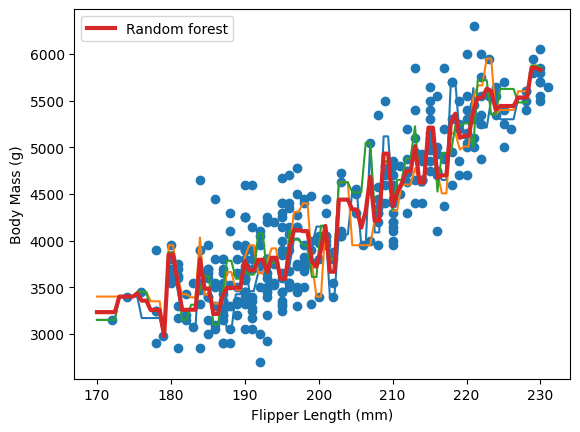

In [6]:
import matplotlib.pyplot as plt

plt.scatter(data, target)

for tree_prediction in tree_predictions:
    plt.plot(data_new, tree_prediction)

plt.plot(
    data_new,
    forest_predictions,
    label="Random forest",
    linewidth=3,
)

plt.xlabel(feature_name)
plt.ylabel(target_name)
plt.legend()
plt.show()

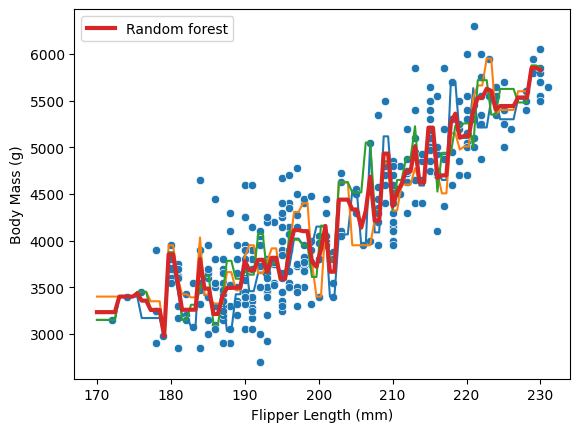

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=data[feature_name], y=target)

for tree_prediction in tree_predictions:
    plt.plot(data_new[feature_name], tree_prediction)

plt.plot(
    data_new[feature_name],
    forest_predictions,
    label="Random forest",
    linewidth=3,
)

plt.xlabel(feature_name)
plt.ylabel(target_name)
plt.legend()
plt.show()